# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**AlexNet Augmented Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating an AlexNet model on the Pneumonia dataset with data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.alexnet_utils import build_alexnet, DropoutRateScheduler
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

2025-03-23 22:49:01.336974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742770141.352565   17645 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742770141.357194   17645 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-23 22:49:01.373235: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Core Variables

In [2]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'alexnet_augmented' # Name of the model to be saved
BEST_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_best_model.keras'
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_pneumonia_model.keras'

# Training parameters
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.3
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

# Data Loading & Preprocessing

In [3]:
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_data(
        DATA_PATH, 
        augment=True, 
        batch_size=BATCH_SIZE
    )


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)

Applying data augmentation to training data...


I0000 00:00:1742770151.667265   17645 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3490 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 6.1


# AlexNet Model

## Creation & Compilation

In [4]:
# Create and compile model
model = build_alexnet(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │             

 Total params: 29,589,058 (112.87 MB)

 Trainable params: 29,569,922 (112.80 MB)

 Non-trainable params: 19,136 (74.75 KB)

## Callback Definition

In [5]:
# Get callbacks
callbacks = get_callbacks(BEST_MODEL_PATH, monitor=CHOSEN_METRIC, mode='max')
dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=EPOCHS)
callbacks.append(dropout_scheduler)

## Training

Epoch 1: dropout rate set to 0.5000
Epoch 1/50


I0000 00:00:1742770311.394445   18774 service.cc:148] XLA service 0x7c37f0002ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742770311.394702   18774 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1050 Ti with Max-Q Design, Compute Capability 6.1
2025-03-23 22:51:51.588388: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742770312.061791   18774 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-23 22:51:52.784660: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[32,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cud

  2/148 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - AUC: 0.6453 - accuracy: 0.5938 - loss: 0.9136 

I0000 00:00:1742770320.212767   18774 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - AUC: 0.8921 - accuracy: 0.8249 - loss: 0.9203

2025-03-23 22:52:13.203523: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[4,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-23 22:52:13.369363: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[4,384,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,256,7,7]{3,2,1,0}, f32[384,256,3,3]{3,2,1,0}, f32[384]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward",

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - AUC: 0.8924 - accuracy: 0.8252 - loss: 0.9178

2025-03-23 22:52:19.527113: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[12,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-23 22:52:19.739504: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[12,384,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,256,7,7]{3,2,1,0}, f32[384,256,3,3]{3,2,1,0}, f32[384]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForwa

148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 148ms/step - AUC: 0.8926 - accuracy: 0.8254 - loss: 0.9153 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 7.4994 - learning_rate: 0.0010
Epoch 2: dropout rate set to 0.4960
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - AUC: 0.9595 - accuracy: 0.8933 - loss: 0.2815 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 2.9189 - learning_rate: 0.0010
Epoch 3: dropout rate set to 0.4920
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - AUC: 0.9709 - accuracy: 0.9085 - loss: 0.2237 - val_AUC: 0.8478 - val_accuracy: 0.7481 - val_loss: 1.3492 - learning_rate: 0.0010
Epoch 4: dropout rate set to 0.4880
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - AUC: 0.9763 - accuracy: 0.9208 - loss: 0.1964 - val_AUC: 0.9852 - val_accuracy: 0.9198 - val_loss: 0.1578 - learning_rate: 0.0010
Epoch 5: dropout rate set to 0.4840
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - AUC: 0.9757 - accuracy: 0.9178 - loss: 0.2035 - val_AUC: 0.9046 -

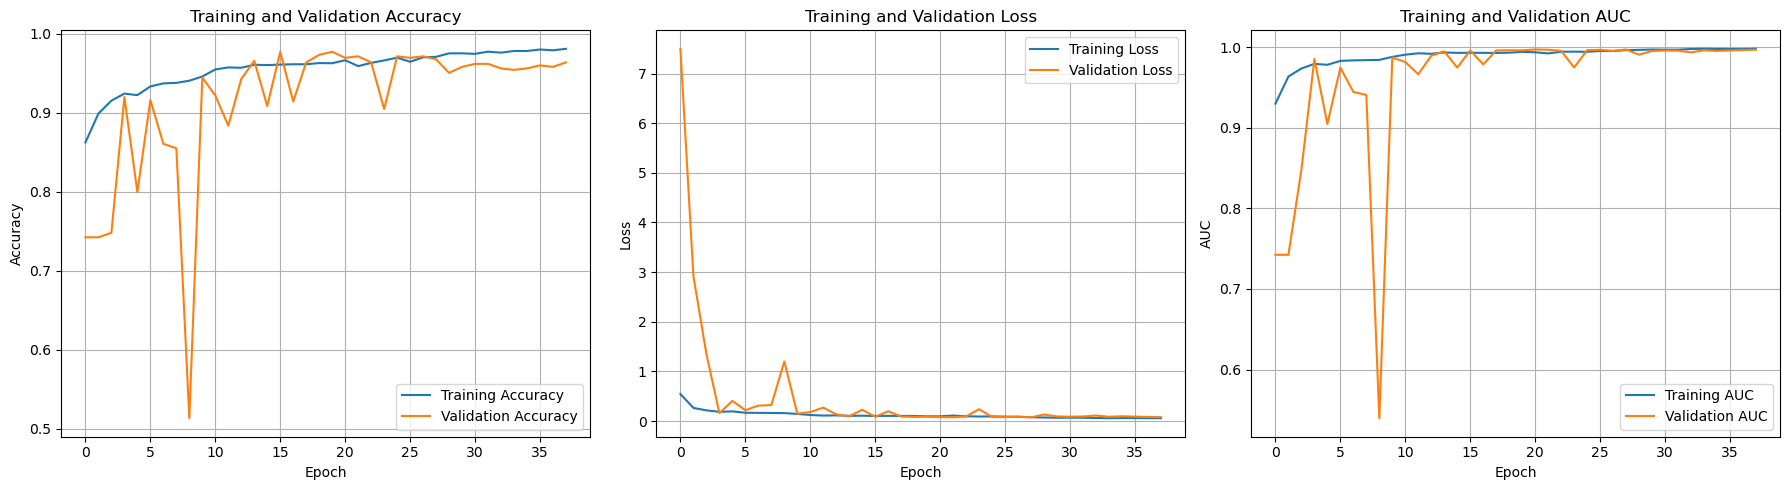

In [6]:
# Train model
history = model.fit(
        train_dataset,
        validation_data=(val_images, val_labels),
        epochs=EPOCHS,
        callbacks=callbacks
    )

# Plot training history
plot_training_history(history)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - AUC: 0.9272 - accuracy: 0.8477 - loss: 0.4847

2025-03-23 23:02:31.952553: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[16,256,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,96,14,14]{3,2,1,0}, f32[256,96,3,3]{3,2,1,0}, f32[256]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-23 23:02:32.135802: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{} for conv (f32[16,384,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,256,7,7]{3,2,1,0}, f32[384,256,3,3]{3,2,1,0}, f32[384]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForwa

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - AUC: 0.9278 - accuracy: 0.8483 - loss: 0.4808
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


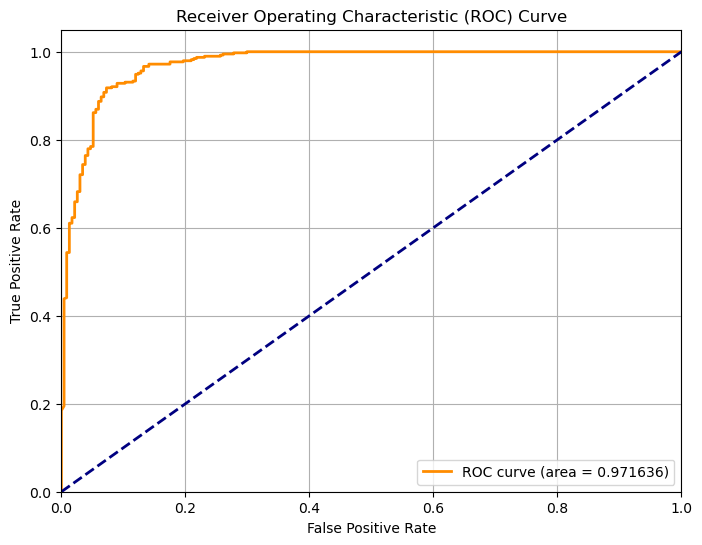

ROC AUC Score: 0.9716


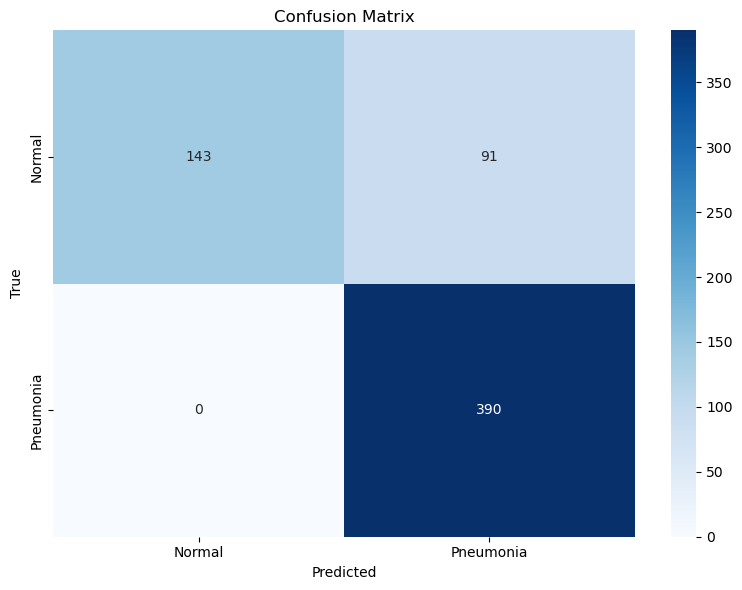

              precision    recall  f1-score   support

      Normal       1.00      0.61      0.76       234
   Pneumonia       0.81      1.00      0.90       390

    accuracy                           0.85       624
   macro avg       0.91      0.81      0.83       624
weighted avg       0.88      0.85      0.84       624



In [7]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

### Comparison

In [8]:
# Load best model from training
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Compare with final model
results_best, results_final = compare_models(best_model, model, test_images, test_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - AUC: 0.9278 - accuracy: 0.8483 - loss: 0.4808
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.9278 - accuracy: 0.8483 - loss: 0.4808
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Best Model (in Training) vs Selected Model (through callbacks):
Test accuracy: 0.854167 vs 0.854167
Test AUC: 0.971636 vs 0.971636
